# **Bank Customer Churn Analysis**

# **Problem Statement**

The bank is experiencing customer churn, which leads to loss of revenue and reduced customer lifetime value. However, the exact factors driving churn are not clearly understood due to the complexity and volume of customer data. There is a need to analyze customer demographics, financial behavior, and engagement patterns to identify key variables influencing churn. By uncovering these insights, the bank can take data-driven actions to improve customer retention and minimize future churn.

# **Objective**
* To analyze how CreditScore, Age, and Balance impact customer churn.

* To study the effect of Geography on churn behavior across different regions.

* To evaluate how customer engagement factors like IsActiveMember and HasCrCard influence churn.

* To examine the relationship between NumOfProducts and customer retention.
.
* To analyze whether Tenure (years with bank) affects customer loyalty.

* To identify patterns between EstimatedSalary and churn behavior.

* To generate insights that help identify high-risk customers likely to churn.



# **Outcome**

* Identify important factors influencing churn such as credit score, age, balance, and activity status.

* Discover patterns like inactive customers and low credit score customers are more likely to churn.

* Provide data-driven insights to help banks reduce customer loss.

# **Domain**

**Banking / Financial Services**

This project falls under the banking sector, focusing on customer relationship management, retention strategies, and business intelligence.

# **Dataset Information**

The dataset contains customer-level information from a bank, including demographics, account details, and activity status.

**Source:** Hugging Face (SunnyShaurya – Bank Customer Churn Dataset)

**Dataset Column/features Description:**

CustomerId – Unique customer identifier

CreditScore – Customer’s creditworthiness

Geography – Customer’s location

Age – Customer age

Tenure – Years with the bank

Balance – Account balance

NumOfProducts – Number of bank products used

HasCrCard – Credit card ownership status

IsActiveMember – Activity status of the customer

EstimatedSalary – Customer’s estimated income

Exited – Target variable (1 = churned, 0 = retained)

# **Importing Libraries and Load dataset**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as px

In [ ]:
df = pd.read_csv("https://raw.githubusercontent.com/jayanthidesign/Bank-Customer-Churn-Dataset/main/bank_customer_churn.csv")

In [ ]:
df

,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,15647311,Hill,608,Spain,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,15619304,Onio,502,France,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,15701354,Boni,699,France,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,15737888,Mitchell,850,Spain,43.0,2,125510.82,1,NaN,1.0,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9997,15584532,Liu,709,France,36.0,7,0.00,1,0.0,1.0,42085.58,1
9998,15682355,Sabbatini,772,Germany,42.0,3,75075.31,2,1.0,0.0,92888.52,1
9999,15682355,Sabbatini,772,Germany,42.0,3,75075.31,2,1.0,0.0,92888.52,1
10000,15628319,Walker,792,France,28.0,4,130142.79,1,1.0,0.0,38190.78,0


In [ ]:
df.head()

,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,42.0,2,0.00,1,1.0,1.0,101348.88,1
1,15647311,Hill,608,Spain,41.0,1,83807.86,1,0.0,1.0,112542.58,0
2,15619304,Onio,502,France,42.0,8,159660.80,3,1.0,0.0,113931.57,1
3,15701354,Boni,699,France,39.0,1,0.00,2,0.0,0.0,93826.63,0
4,15737888,Mitchell,850,Spain,43.0,2,125510.82,1,NaN,1.0,79084.10,0


In [ ]:
df.tail()

,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9997,15584532,Liu,709,France,36.0,7,0.00,1,0.0,1.0,42085.58,1
9998,15682355,Sabbatini,772,Germany,42.0,3,75075.31,2,1.0,0.0,92888.52,1
9999,15682355,Sabbatini,772,Germany,42.0,3,75075.31,2,1.0,0.0,92888.52,1
10000,15628319,Walker,792,France,28.0,4,130142.79,1,1.0,0.0,38190.78,0
10001,15628319,Walker,792,France,28.0,4,130142.79,1,1.0,0.0,38190.78,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10002 non-null  int64  
 1   Surname          10002 non-null  object 
 2   CreditScore      10002 non-null  int64  
 3   Geography        10001 non-null  object 
 4   Age              10001 non-null  float64
 5   Tenure           10002 non-null  int64  
 6   Balance          10002 non-null  float64
 7   NumOfProducts    10002 non-null  int64  
 8   HasCrCard        10001 non-null  float64
 9   IsActiveMember   10001 non-null  float64
 10  EstimatedSalary  10002 non-null  float64
 11  Exited           10002 non-null  int64  
dtypes: float64(5), int64(5), object(2)
memory usage: 937.8+ KB


In [ ]:
df.columns

Index(['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Age', 'Tenure',
       'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited'],
      dtype='object')

In [ ]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000200e+04,10002.000000,10001.000000,10002.000000,10002.000000,10002.000000,10001.000000,10001.000000,10002.000000,10002.000000
mean,1.569093e+07,650.555089,38.922311,5.012498,76491.112875,1.530194,0.705529,0.514949,100083.331145,0.203759
std,7.193177e+04,96.661615,10.487200,2.891973,62393.474144,0.581639,0.455827,0.499801,57508.117802,0.402812
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.562852e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.000000,0.000000,50983.750000,0.000000
50%,1.569073e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.000000,1.000000,100185.240000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127647.840000,2.000000,1.000000,1.000000,149383.652500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [ ]:
df.shape

(10002, 12)

# **Data Cleaning and Pre-processing**

**Handle Duplicates**

In [ ]:
df.duplicated().sum()

np.int64(2)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

**Handling Missing values**

In [ ]:
df=df.dropna(subset=['Geography','Age'])

In [ ]:
df['HasCrCard']=df['HasCrCard'].fillna(df['HasCrCard'].mode()[0])
df['IsActiveMember']=df['IsActiveMember'].fillna(df['IsActiveMember'].mode()[0])

In [ ]:
df.isnull().sum()

,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0


**Changing Datatype**

In [ ]:
df.dtypes

,0
CustomerId,int64
Surname,object
CreditScore,int64
Geography,object
Age,float64
Tenure,int64
Balance,float64
NumOfProducts,int64
HasCrCard,float64
IsActiveMember,float64


In [ ]:
df['Age']=df['Age'].astype(int)
df['HasCrCard']=df['HasCrCard'].astype(int)
df['IsActiveMember']=df['IsActiveMember'].astype(int)

**Dropping 'Surname' Column**

In [ ]:
df=df.drop(['Surname','CustomerId'],axis=1)

**Renaming 'Exited' column to 'Churn'**

In [ ]:
df.rename(columns={'Exited':'Churn'},inplace =True)

**Adding 'Age group' Column**

In [ ]:
def Age_group(Age):
  if Age <=30:
    return 'Below 30'
  elif Age >30 and Age <=50:
    return '30-50'
  else:
    return 'Above 50'






In [ ]:
df['Age_group']=df['Age'].apply(Age_group)

**Adding 'Tenure group' Column**

In [ ]:
def Tenure_group(Tenure):
  if Tenure <=3:
    return 'New'
  elif Tenure >3 and Tenure <=6:
    return 'Regular'
  else:
    return 'Loyal'



In [ ]:
df['Tenure_group']=df['Tenure'].apply(Tenure_group)

**Skewness**

In [ ]:
df['CreditScore'].skew()

np.float64(-0.07156106490597913)

In [ ]:
df['Age'].skew()

np.float64(1.0115894433133727)

**Treat Outliers**

In [ ]:
Q1 = df['Balance'].quantile(0.25)
Q3 = df['Balance'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Balance'] < lower_bound) | (df['Balance'] > upper_bound)]

outliers.shape

(0, 12)

**Interpretation**

* There are no outliers detected in the Balance column using the IQR method.

In [ ]:
df.head()

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn,Age_group,Tenure_group
0,619,France,42,2,0.00,1,1,1,101348.88,1,30-50,New
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0,30-50,New
2,502,France,42,8,159660.80,3,1,0,113931.57,1,30-50,Loyal
3,699,France,39,1,0.00,2,0,0,93826.63,0,30-50,New
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0,30-50,New


# **EDA and Visualizations**



## **Distribution of customer age**

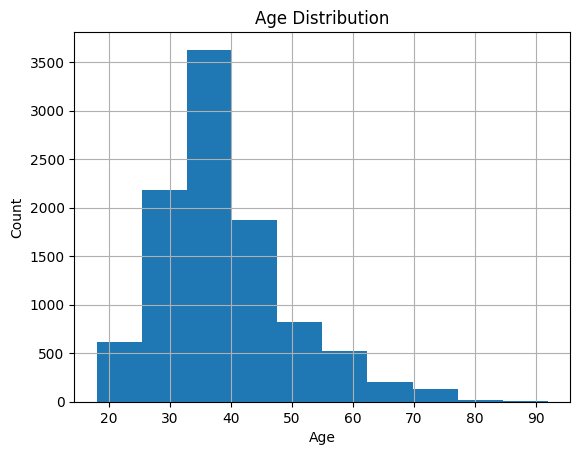

In [ ]:
df['Age'].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Histogram showing the distribution of customer age.

**Features used:** Age

**Interpretation:**

* Most customers are in the middle-age group(35-45), with fewer older customers.

## **Churn Distribution**

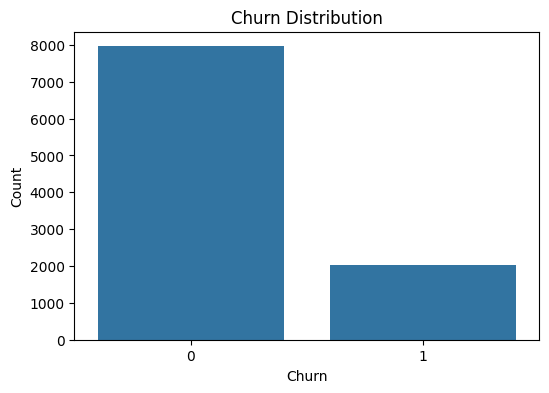

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df,x='Churn')
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.show()

Countplot shows the number of customers who stayed and who churned.

**Features used:** Churn.

**Interpretation:**

* It indicates that most customers did not churn, but a significant number still left the bank.

## **Balance Distribution**

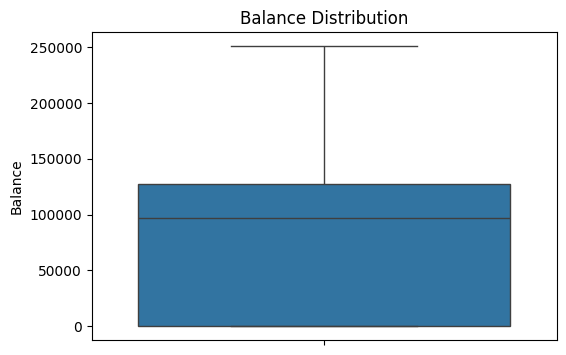

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df,y='Balance')
plt.title('Balance Distribution')
plt.show()

Boxplot showing the distribution of customer account balance.

**Features used:** Balance.


**Interpretation:**
* It shows that most customers have low to medium balance, with some customers having very high balances, indicating variation in customer value.

## **Churn Rate Across Countries**

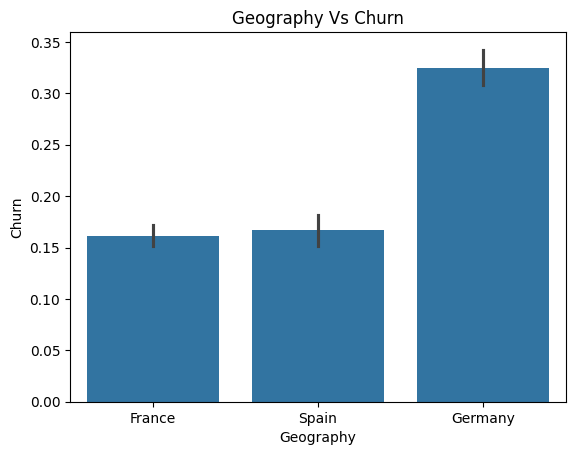

In [ ]:
sns.barplot(data=df,x='Geography',y='Churn')
plt.title('Geography Vs Churn')
plt.show()

Bar plot shows the churn rate across countries.

**Features used:** Geography and Churn.

**Interpretation:**



* Germany has more churned customers.

## **Relationship between Estimated Salary and Balance**

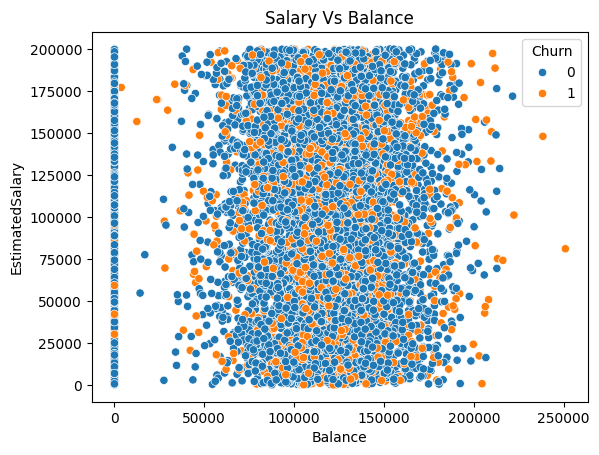

In [ ]:
sns.scatterplot(data=df,y='EstimatedSalary',x='Balance',hue='Churn')
plt.title('Salary Vs Balance')
plt.show()

Scatter plot showing the relationship between Estimated Salary and Balance, with churn highlighted.

**Features used:** EstimatedSalary, Balance, and Churn.

**Interpretation:**

* The scatter plot shows no strong relationship between salary and balance, and churn is evenly distributed, indicating salary is not a key factor affecting churn.

## **Relationship between numeric variables**

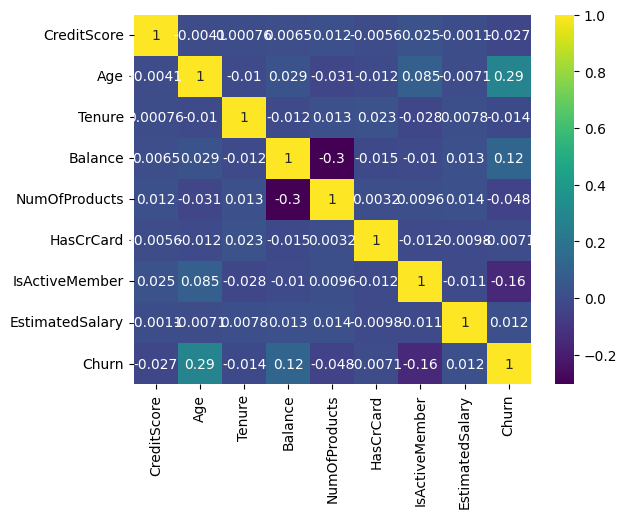

In [ ]:
numeric_col=df.select_dtypes(include=np.number)
corr=numeric_col.corr()
sns.heatmap(corr,annot=True,cmap='viridis')
plt.show()

The correlation heat map shows relationship between numeric variables.

**Features used:** Numeric columns

**Interpretation:**
*  Most variables show very low correlation with churn
  
*  Age (≈ 0.29) → moderate positive relation with churn
*  IsActiveMember (≈ -0.16) → negative relation (active customers churn less)
*  Balance (≈ 0.12) → slight positive relation
*  Other variables like CreditScore, Salary → very weak correlation

## **Customer Behavior Analysis by Geography and Churn**

In [ ]:
grouped = df.groupby(['Geography','Churn'])['Balance'].mean()
print("Average Balance by:",grouped)

Average Balance by: Geography  Churn
France     0         60335.961702
           1         71192.795728
Germany    0        119427.106696
           1        120361.075590
Spain      0         59678.070470
           1         72513.352446
Name: Balance, dtype: float64


This table shows the average account balance of customers grouped by Geography and Churn status (0 = retained, 1 = churned).


**Features used:** Geography, Churn, Balance


**Interpretations:**

France:
Customers who churned have a higher average balance (71k) than those retained (60k)

Germany:
Average balance is similar for churned (120k) and retained (119k) customers

Spain:
Churned customers have a higher balance (72k) than retained (59k)





## **Multivariate Relationship Analysis of Customer Features**

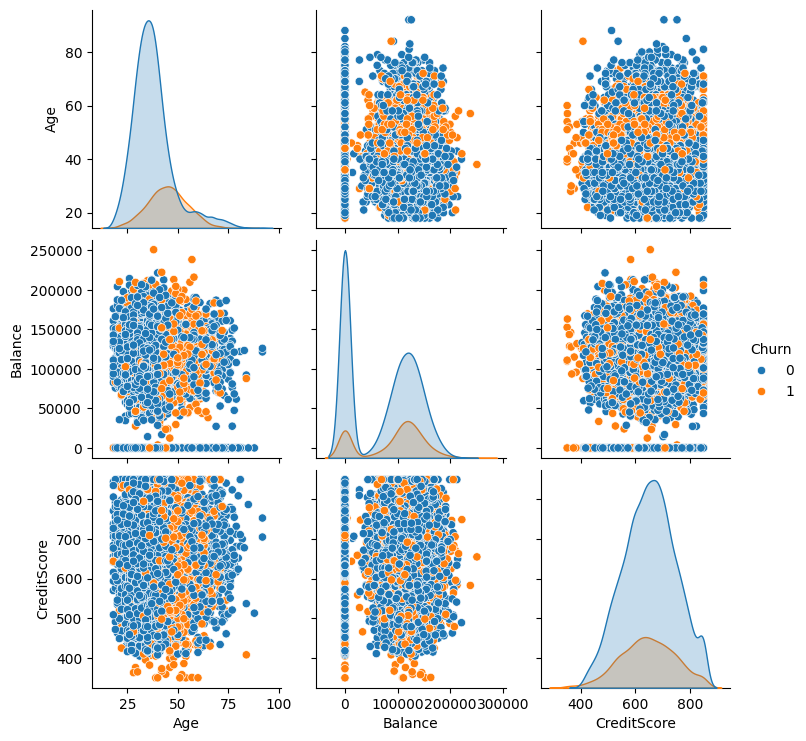

In [ ]:
sns.pairplot(df[['Age','Balance','CreditScore','Churn']], hue='Churn')
plt.show()

The Pairplot shows the multivariate relationship analysis of customer features.

**Features used:** Age ,Balance, Creditscore and Churn.

**Interpretation:**
No clear linear relationship between Age, Balance, and CreditScore
Churned and non-churned customers.

Slight pattern:
Churned customers are slightly older


## **Churn Analysis by Customer Tenure Group**

In [ ]:
pd.pivot_table(df, values='NumOfProducts', index='Tenure_group', columns='Churn',aggfunc=np.mean)

Churn,0,1
Tenure_group,,
Loyal,1.543340,1.492733
New,1.537821,1.485830
Regular,1.552966,1.442434


This table shows the average value for customers grouped by Tenure Group (Loyal, New, Regular) and Churn.

**Features used:** NumOfProducts,Tenure Group,Churn.

**Interpretation:**

Loyal customers:
Churned and retained values are almost similar (~1.49–1.54).

New customers:
Again, very small difference between churned and retained.

Regular customers:
Slight difference, but still not very significant.

## **Churn Rate By Credit Score**

In [ ]:
import plotly.express as px

credit_data = df.groupby('CreditScore')['Churn'].mean().reset_index()
plt.figure(figsize=(4,4))
fig = px.bar(
    credit_data,
    x='CreditScore',
    y='Churn',
    title='Churn Rate by Credit Score'
)

fig.show()

<Figure size 400x400 with 0 Axes>


**Fearures used:** CreditScore, Churn.

**Interpretation**

Churn values are spread across all credit score ranges
No clear trend like “low score = high churn”
Some spikes due to fewer data points at certain scores.

## **Download clean data for Dashboard creation using PowerBI**

In [ ]:
df.to_csv("bank_customer_churn.csv",index=False)

In [ ]:
df

,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Churn,Age_group,Tenure_group
0,619,France,42,2,0.00,1,1,1,101348.88,1,30-50,New
1,608,Spain,41,1,83807.86,1,0,1,112542.58,0,30-50,New
2,502,France,42,8,159660.80,3,1,0,113931.57,1,30-50,Loyal
3,699,France,39,1,0.00,2,0,0,93826.63,0,30-50,New
4,850,Spain,43,2,125510.82,1,1,1,79084.10,0,30-50,New
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,39,5,0.00,2,1,0,96270.64,0,30-50,Regular
9996,516,France,35,10,57369.61,1,1,1,101699.77,0,30-50,Loyal
9997,709,France,36,7,0.00,1,0,1,42085.58,1,30-50,Loyal
9998,772,Germany,42,3,75075.31,2,1,0,92888.52,1,30-50,New


# **Dashboard**

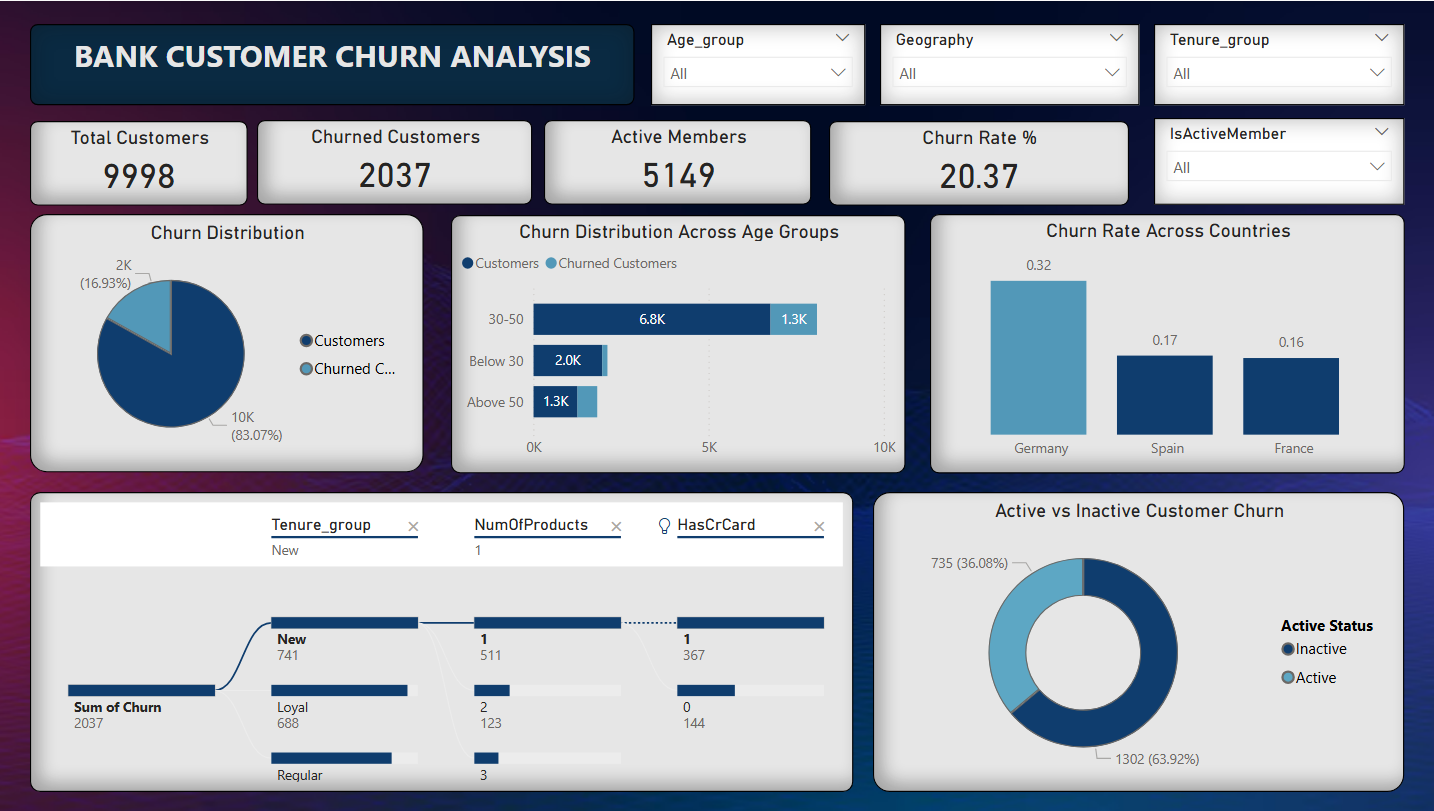

# **Summary:**

* Out of 9,998 customers, 2,037 customers left the bank, resulting in a 20.37% churn rate—meaning roughly 1 in 5 customers churned.
* Among those who left, inactive customers contributed 1,302 (63.92%), while active customers accounted for 735 (36.08%), showing that inactivity is a major driver of churn.
* Looking at age groups, customers aged 30–50 made up the largest segment, with 6.8K total customers and 1.3K churns, making them the biggest contributors to overall churn.
* By geography, Germany recorded the highest churn rate at 32%, compared to Spain (17%) and France (16%), indicating a significant regional difference.
* Customers with only 1 product and a credit card are the most likely to churn, showing that low engagement customers tend to leave more.
* Overall, the numbers show that customer churn is highest among inactive, middle-aged, new, and low-product customers, especially in Germany.

# **Key Insights:**

* Most customers are in the middle-age group (35–45).

* Germany’s churn rate is around 32–33%, which is almost double that of France and Spain.

* A significant number of customers have left the bank despite majority staying
Inactive customers are more likely to leave.

* Older customers show a slightly higher chance of churn.

* Customers with higher balances in France and Spain are more likely to churn.

* Credit score and salary have very little impact on churn.

* There is no strong relationship between salary and balance
Customer churn depends on multiple factors, not just one.

# **Business Recommendations**

**Improve Customer Engagement**

* Focus on inactive customers (highest churn risk)
Send reminders, offers, and personalized messages.
* Goal: Increase activity and reduce churn.

**Target High-risk customers**

* Identify customers who are:
Older
Inactive
Using fewer products
Create special retention programs.
* Goal: Prevent them from leaving.

**Retain High-Value Customers**

* Customers with high balance (especially in France & Spain) need attention
Offer:
Premium services, Loyalty rewards.
* Goal: Protect valuable customers.

**Increase Product Usage**

* Encourage customers to use more bank products
Example: bundle offers (account + card + loan).

* Goal: Higher engagement → lower churn.

**Do Not Rely Only on Credit Score or Salary**

* These factors have low impact on churn.

* Focus more on behavior (activity, engagement).



# **Conclusion:**

In this bank customer churn project, 20.37% of customers have left, with churn concentrated among inactive customers, those holding only one product, and new customers. Certain segments, such as customers in Germany and the 30–50 age group, are at higher risk of leaving. The analysis highlights key factors influencing churn, providing actionable insights to improve customer retention and target high-risk segments effectively.